# Notebook 02 — Exploratory Data Analysis

## Consumer Spending Intelligence | Credit Card Transactions
**Notebook goal:** Understand the shape, composition, and statistical properties of the
transaction dataset before any trend or hypothesis analysis begins.

---

### What this notebook covers
1. Transaction amount distribution and statistical profiling
2. Spending composition by category
3. Demographic breakdown — gender, age group, top occupations
4. Transaction frequency patterns — hour of day, day of week, month
5. Formal distribution test — is transaction amount normally distributed?

---

*This notebook covers Objective 2 — distributions, category mix, and demographic composition.*

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
import os
warnings.filterwarnings("ignore")

# path to cleaned parquet
PARQUET_PATH = "../data/processed/transactions_clean.parquet"

# load data
df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

# derive age column — used throughout this notebook
df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

# derive time-based columns
df["hour"]       = df["trans_date_trans_time"].dt.hour
df["day_of_week"]= df["trans_date_trans_time"].dt.day_name()
df["month"]      = df["trans_date_trans_time"].dt.to_period("M")
df["year"]       = df["trans_date_trans_time"].dt.year

# portfolio color theme
THEME = {
    "bg"      : "#0d1117",
    "card"    : "#161b27",
    "primary" : "#7c3aed",
    "blue"    : "#3b82f6",
    "emerald" : "#10b981",
    "crimson" : "#ef4444",
    "amber"   : "#f59e0b",
    "text"    : "#e2e8f0",
    "subtext" : "#94a3b8",
    "grid"    : "#1e2a3a"
}

# global matplotlib style matching portfolio theme
plt.rcParams.update({
    "figure.facecolor"  : THEME["bg"],
    "axes.facecolor"    : THEME["card"],
    "axes.edgecolor"    : THEME["grid"],
    "axes.labelcolor"   : "#e2e8f0",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#cbd5e1",
    "ytick.color"       : "#cbd5e1",
    "grid.color"        : THEME["grid"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "text.color"        : "#ffffff",
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 13,
    "figure.titlesize"  : 14,
    "legend.fontsize"   : 10,
})

plt.rcParams["savefig.facecolor"] = THEME["bg"]
CHARTS_DIR = "../outputs/charts/"
os.makedirs(CHARTS_DIR, exist_ok=True)
print(f"Charts directory : {CHARTS_DIR}")

print("Data loaded successfully")
print(f"Shape : {df.shape}")
print(f"Age range : {df['age'].min()} to {df['age'].max()} years")

Charts directory : ../outputs/charts/
Data loaded successfully
Shape : (1296675, 24)
Age range : 13 to 95 years


## Step 1 — Transaction Amount Distribution

We profile the statistical properties of transaction amounts and formally test
whether the distribution is normal. This justifies all downstream decisions to
use median-based statistics and non-parametric hypothesis tests rather than
mean-based or parametric alternatives.

Transaction amount summary:
  Count  : 1,296,675
  Mean   : $70.35
  Median : $47.52
  Std    : $160.32
  Min    : $1.00
  Max    : $28,948.90
  Skew   : 42.278
  Kurt   : 4545.645

Kolmogorov-Smirnov normality test:
  H0     : transaction amounts follow a normal distribution
  KS stat: 0.3327
  p-value: 0.000000
  Result : Reject H0 — distribution is not normal


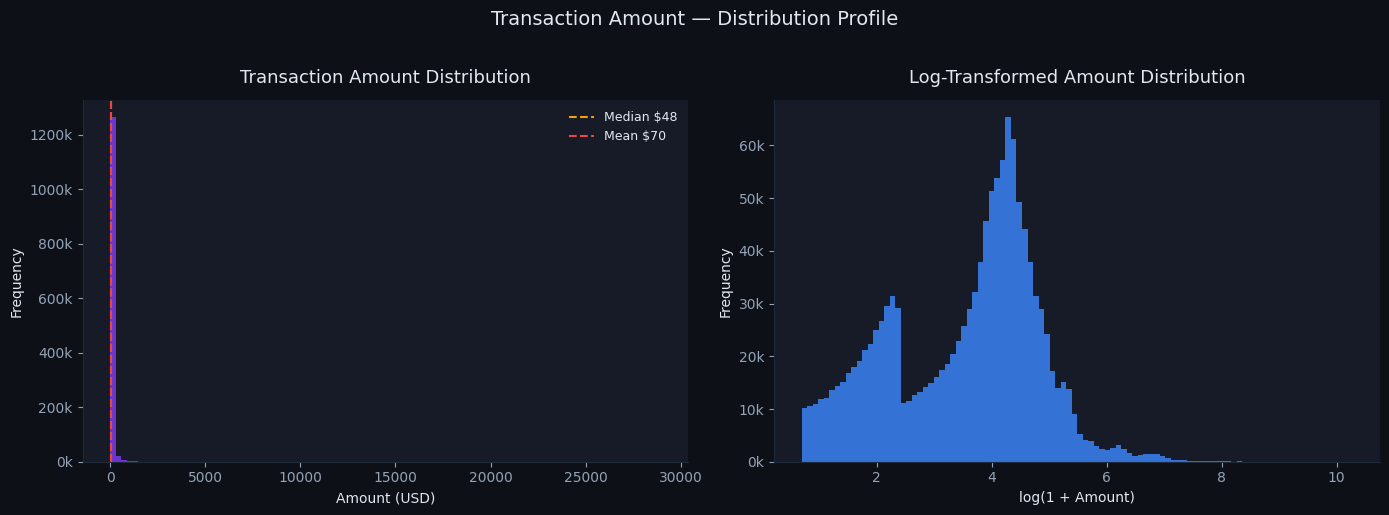

Chart saved


In [ ]:
from scipy import stats

# statistical summary of transaction amounts
amt = df["amt"]

print("Transaction amount summary:")
print(f"  Count  : {len(amt):,}")
print(f"  Mean   : ${amt.mean():,.2f}")
print(f"  Median : ${amt.median():,.2f}")
print(f"  Std    : ${amt.std():,.2f}")
print(f"  Min    : ${amt.min():,.2f}")
print(f"  Max    : ${amt.max():,.2f}")
print(f"  Skew   : {amt.skew():.3f}")
print(f"  Kurt   : {amt.kurtosis():.3f}")

# formal normality test — KS test against normal distribution
# shapiro-wilk is not used here as it is unreliable above 5000 samples
ks_stat, ks_pval = stats.kstest(
    amt,
    "norm",
    args=(amt.mean(), amt.std())
)

print(f"\nKolmogorov-Smirnov normality test:")
print(f"  H0     : transaction amounts follow a normal distribution")
print(f"  KS stat: {ks_stat:.4f}")
print(f"  p-value: {ks_pval:.6f}")
print(f"  Result : {'Reject H0 — distribution is not normal' if ks_pval < 0.05 else 'Fail to reject H0'}")

# plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(THEME["bg"])

# histogram — log scale on y axis to handle the long tail
axes[0].hist(amt, bins=100, color=THEME["primary"], alpha=0.85, edgecolor="none")
axes[0].set_title("Transaction Amount Distribution", fontsize=13, pad=12)
axes[0].set_xlabel("Amount (USD)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(amt.median(), color=THEME["amber"],  linewidth=1.5, linestyle="--", label=f"Median ${amt.median():.0f}")
axes[0].axvline(amt.mean(),   color=THEME["crimson"], linewidth=1.5, linestyle="--", label=f"Mean ${amt.mean():.0f}")
axes[0].legend(fontsize=9, facecolor=THEME["card"], edgecolor="none", labelcolor=THEME["text"])
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# log-transformed distribution to show tail behaviour clearly
axes[1].hist(np.log1p(amt), bins=100, color=THEME["blue"], alpha=0.85, edgecolor="none")
axes[1].set_title("Log-Transformed Amount Distribution", fontsize=13, pad=12)
axes[1].set_xlabel("log(1 + Amount)")
axes[1].set_ylabel("Frequency")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

plt.suptitle("Transaction Amount — Distribution Profile", fontsize=14,
             color=THEME["text"], y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}eda_amt_distribution.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()

## Step 2 — Spending Composition by Category

We identify which categories drive transaction volume and revenue.
Volume and revenue tell different stories — a high-volume category is not
necessarily a high-revenue category.

Category summary:
      category  transaction_count  total_revenue  revenue_share  median_amt
   grocery_pos             123638    14460822.38          15.85     105.120
  shopping_pos             116672     9307993.61          10.20       7.760
  shopping_net              97543     8625149.68           9.46       8.440
 gas_transport             131659     8351732.29           9.16      62.840
          home             123115     7173928.11           7.86      48.290
     kids_pets             113035     6503680.16           7.13      47.180
 entertainment              94014     6036678.56           6.62      50.740
      misc_net              63287     5117709.26           5.61       9.840
      misc_pos              79655     5009582.50           5.49      13.920
   food_dining              91461     4672459.44           5.12      42.030
health_fitness              85879     4653108.02           5.10      42.850
        travel              40507     4516721.68           4.95       

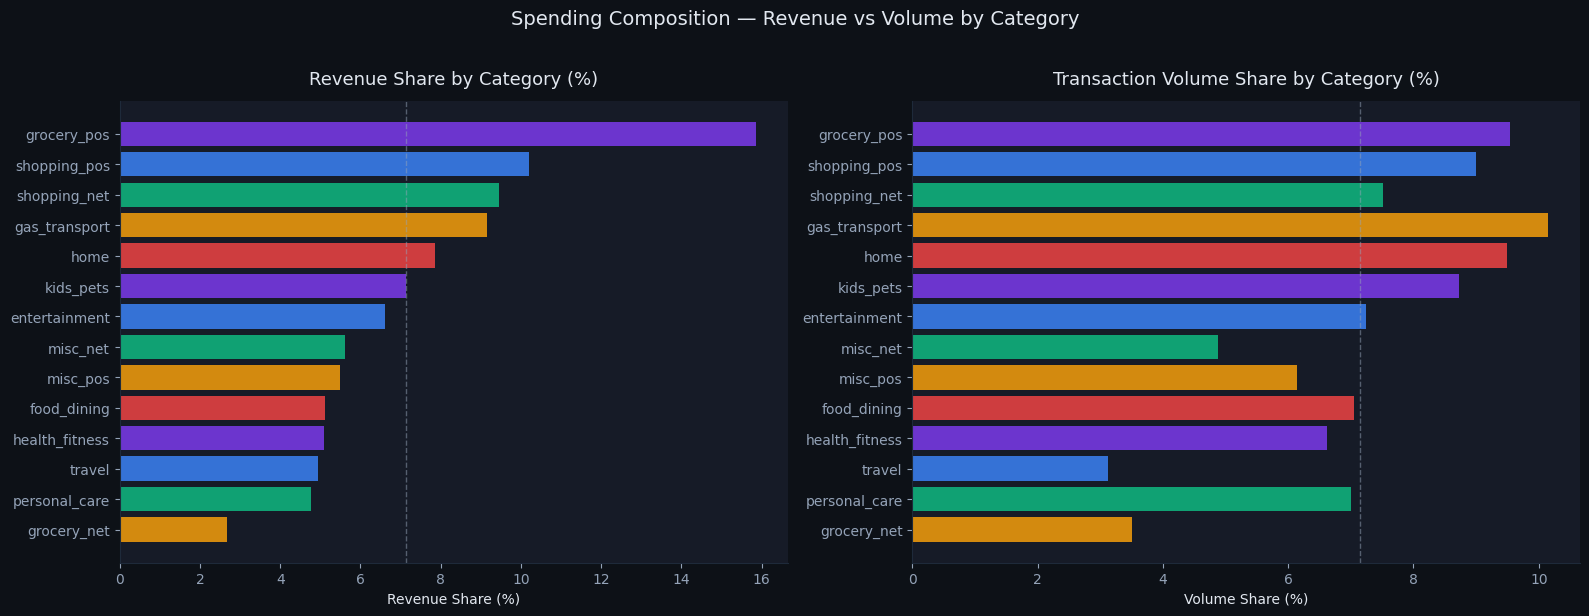

Chart saved


In [ ]:
# category summary — volume and revenue
cat_summary = (
    df.groupby("category", observed=True)["amt"]
    .agg(
        transaction_count="count",
        total_revenue="sum",
        median_amt="median",
        mean_amt="mean"
    )
    .sort_values("total_revenue", ascending=False)
    .reset_index()
)

cat_summary["revenue_share"] = (
    cat_summary["total_revenue"] / cat_summary["total_revenue"].sum() * 100
).round(2)

cat_summary["volume_share"] = (
    cat_summary["transaction_count"] / cat_summary["transaction_count"].sum() * 100
).round(2)

print("Category summary:")
print(cat_summary[["category", "transaction_count", "total_revenue",
                    "revenue_share", "median_amt"]].to_string(index=False))

# chart — side by side volume vs revenue share
categories  = cat_summary["category"].astype(str).tolist()
rev_shares  = cat_summary["revenue_share"].tolist()
vol_shares  = cat_summary["volume_share"].tolist()

# generate a gradient of violet shades for bars
bar_colors = [THEME["primary"], THEME["blue"], THEME["emerald"],
              THEME["amber"], THEME["crimson"]]
color_cycle = [bar_colors[i % len(bar_colors)] for i in range(len(categories))]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(THEME["bg"])

# revenue share
axes[0].barh(categories[::-1], rev_shares[::-1], color=color_cycle[::-1],
             alpha=0.85, edgecolor="none")
axes[0].set_title("Revenue Share by Category (%)", fontsize=13, pad=12)
axes[0].set_xlabel("Revenue Share (%)")
axes[0].axvline(100/len(categories), color=THEME["subtext"],
                linewidth=1, linestyle="--", alpha=0.5)

# volume share
axes[1].barh(categories[::-1], vol_shares[::-1], color=color_cycle[::-1],
             alpha=0.85, edgecolor="none")
axes[1].set_title("Transaction Volume Share by Category (%)", fontsize=13, pad=12)
axes[1].set_xlabel("Volume Share (%)")
axes[1].axvline(100/len(categories), color=THEME["subtext"],
                linewidth=1, linestyle="--", alpha=0.5)

plt.suptitle("Spending Composition — Revenue vs Volume by Category",
             fontsize=14, color=THEME["text"], y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}eda_category_composition.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()


## Step 3 — Demographic Breakdown

We profile the customer base by gender, age group, and occupation.
These dimensions will be formally hypothesis tested in Notebook 04.
Here we establish the baseline composition.

Gender breakdown:
gender  transactions  total_revenue  median_amt  revenue_share
     F        709863    49832612.83       43.44          54.63
     M        586812    41389816.07       51.67          45.37

Age group breakdown:
age_group  transactions  total_revenue  median_amt  revenue_share
 Under 18         15508     1023813.45      42.660           1.12
    18-30        254726    17687409.53      46.815          19.39
    31-45        440670    33165483.06      52.500          36.36
    46-60        330582    22379133.00      44.115          24.53
      60+        255189    16966589.86      42.540          18.60

Top 10 occupations by revenue:
                          job  transactions  total_revenue
            Film/video editor          9779      755477.03
          Exhibition designer          9199      652516.73
              Naval architect          8684      636812.33
     Surveyor, land/geomatics          8680      615734.51
     Environmental consultant          7547     

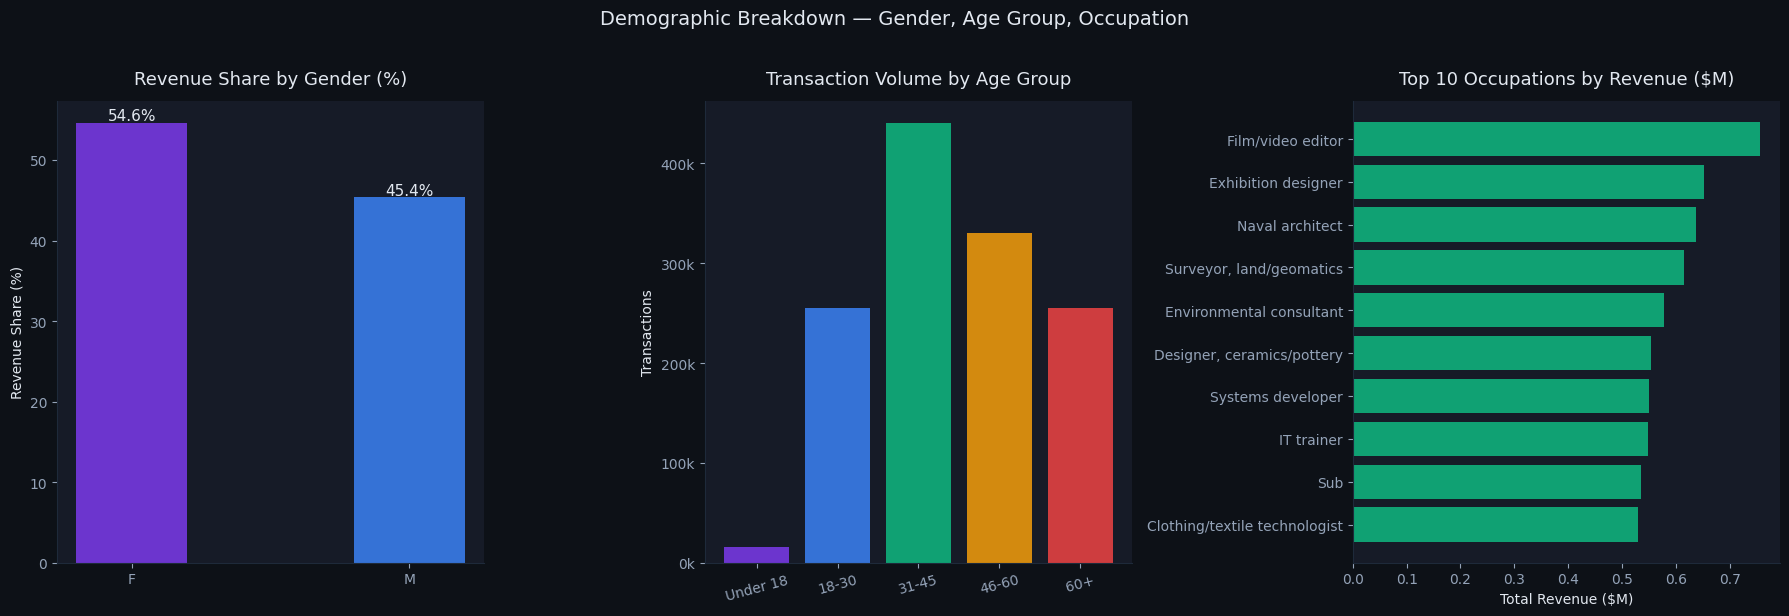

Chart saved


In [6]:
# age group bins
age_bins   = [0, 17, 30, 45, 60, 100]
age_labels = ["Under 18", "18-30", "31-45", "46-60", "60+"]
df["age_group"] = pd.cut(df["age"], bins=age_bins, labels=age_labels, right=True)

# gender split
gender_rev = (
    df.groupby("gender", observed=True)["amt"]
    .agg(transactions="count", total_revenue="sum", median_amt="median")
    .reset_index()
)
gender_rev["revenue_share"] = (
    gender_rev["total_revenue"] / gender_rev["total_revenue"].sum() * 100
).round(2)

print("Gender breakdown:")
print(gender_rev.to_string(index=False))

# age group split
age_rev = (
    df.groupby("age_group", observed=True)["amt"]
    .agg(transactions="count", total_revenue="sum", median_amt="median")
    .reset_index()
)
age_rev["revenue_share"] = (
    age_rev["total_revenue"] / age_rev["total_revenue"].sum() * 100
).round(2)

print("\nAge group breakdown:")
print(age_rev.to_string(index=False))

# top 10 occupations by revenue
top_jobs = (
    df.groupby("job", observed=True)["amt"]
    .agg(transactions="count", total_revenue="sum")
    .sort_values("total_revenue", ascending=False)
    .head(10)
    .reset_index()
)

print("\nTop 10 occupations by revenue:")
print(top_jobs.to_string(index=False))

# chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(THEME["bg"])

# gender — revenue share pie style as bar
gender_colors = [THEME["primary"], THEME["blue"]]
axes[0].bar(gender_rev["gender"].astype(str),
            gender_rev["revenue_share"],
            color=gender_colors, alpha=0.85, edgecolor="none", width=0.4)
axes[0].set_title("Revenue Share by Gender (%)", fontsize=13, pad=12)
axes[0].set_ylabel("Revenue Share (%)")
for i, v in enumerate(gender_rev["revenue_share"]):
    axes[0].text(i, v + 0.3, f"{v:.1f}%",
                 ha="center", color=THEME["text"], fontsize=11)

# age group — transaction count
age_colors = [THEME["primary"], THEME["blue"], THEME["emerald"],
              THEME["amber"], THEME["crimson"]]
axes[1].bar(age_rev["age_group"].astype(str),
            age_rev["transactions"],
            color=age_colors, alpha=0.85, edgecolor="none")
axes[1].set_title("Transaction Volume by Age Group", fontsize=13, pad=12)
axes[1].set_ylabel("Transactions")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[1].tick_params(axis="x", rotation=15)

# top 10 jobs
axes[2].barh(top_jobs["job"].astype(str)[::-1],
             top_jobs["total_revenue"][::-1] / 1e6,
             color=THEME["emerald"], alpha=0.85, edgecolor="none")
axes[2].set_title("Top 10 Occupations by Revenue ($M)", fontsize=13, pad=12)
axes[2].set_xlabel("Total Revenue ($M)")

plt.suptitle("Demographic Breakdown — Gender, Age Group, Occupation",
             fontsize=14, color=THEME["text"], y=1.02)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}eda_demographic_breakdown.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 4 — Temporal Transaction Patterns

We examine when transactions occur across three time dimensions:
- Hour of day — identifies peak spending windows
- Day of week — distinguishes weekday vs weekend behaviour
- Month — surfaces seasonal patterns ahead of formal trend analysis in Notebook 03

These patterns directly inform the hypothesis tests in the next notebook.

Peak transaction hour    : 23:00
Peak transaction day     : Monday
Weekend vs weekday split :
  Weekend transactions   : 451,536 (34.8%)
  Weekday transactions   : 845,139 (65.2%)


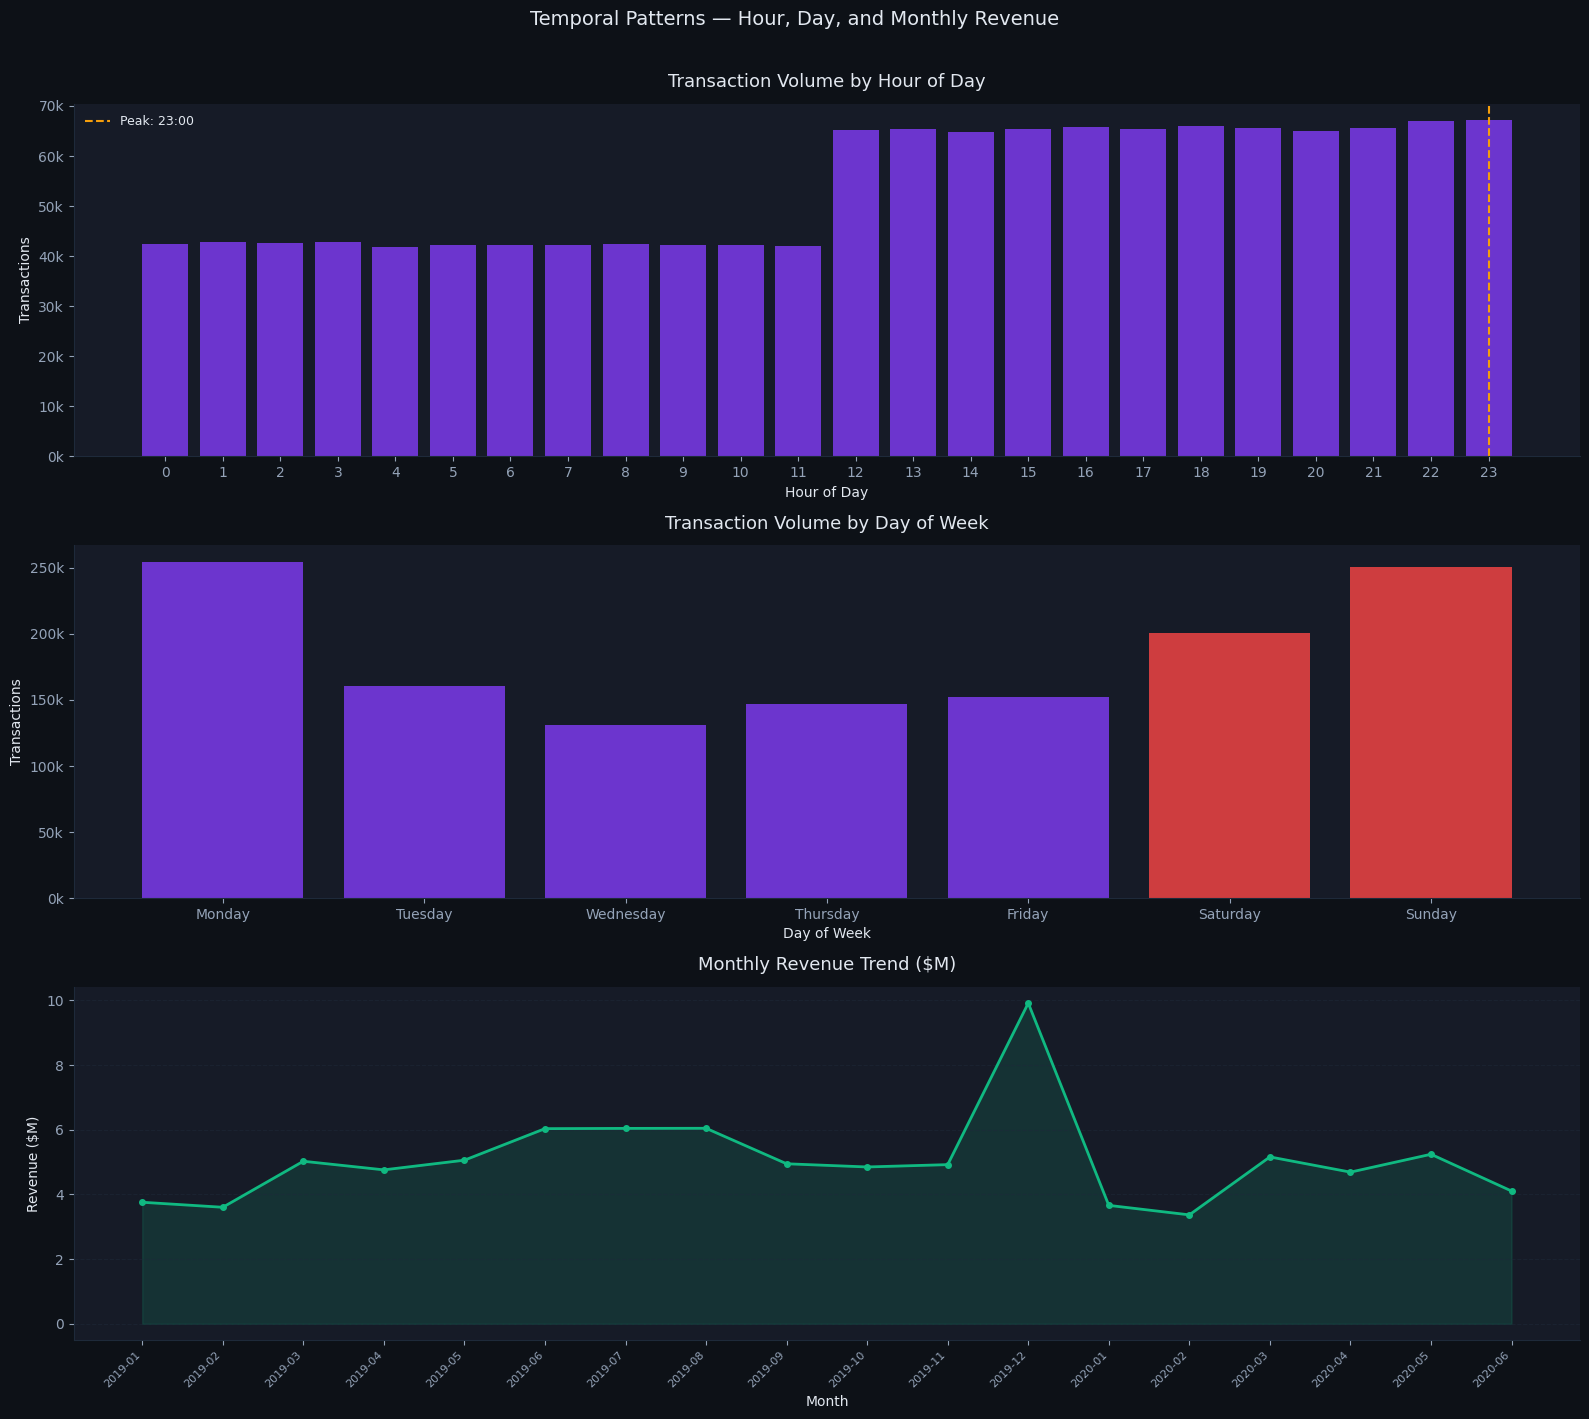

Chart saved


In [7]:
# hour of day aggregation
hour_summary = (
    df.groupby("hour")["amt"]
    .agg(transactions="count", total_revenue="sum")
    .reset_index()
)

# day of week aggregation — ordered correctly
dow_order   = ["Monday", "Tuesday", "Wednesday", "Thursday",
               "Friday", "Saturday", "Sunday"]
dow_summary = (
    df.groupby("day_of_week")["amt"]
    .agg(transactions="count", total_revenue="sum")
    .reindex(dow_order)
    .reset_index()
)

# month aggregation
month_summary = (
    df.groupby("month")["amt"]
    .agg(transactions="count", total_revenue="sum")
    .reset_index()
)
month_summary["month_str"] = month_summary["month"].astype(str)

# print key stats
peak_hour = hour_summary.loc[hour_summary["transactions"].idxmax(), "hour"]
peak_dow  = dow_summary.loc[dow_summary["transactions"].idxmax(), "day_of_week"]
print(f"Peak transaction hour    : {peak_hour}:00")
print(f"Peak transaction day     : {peak_dow}")
print(f"Weekend vs weekday split :")
weekend_mask = df["day_of_week"].isin(["Saturday", "Sunday"])
print(f"  Weekend transactions   : {weekend_mask.sum():,} "
      f"({weekend_mask.mean()*100:.1f}%)")
print(f"  Weekday transactions   : {(~weekend_mask).sum():,} "
      f"({(~weekend_mask).mean()*100:.1f}%)")

# chart — 3 panel temporal view
fig, axes = plt.subplots(3, 1, figsize=(16, 14))
fig.patch.set_facecolor(THEME["bg"])

# hour of day
axes[0].bar(hour_summary["hour"], hour_summary["transactions"],
            color=THEME["primary"], alpha=0.85, edgecolor="none")
axes[0].set_title("Transaction Volume by Hour of Day", fontsize=13, pad=12)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Transactions")
axes[0].set_xticks(range(0, 24))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))
axes[0].axvline(peak_hour, color=THEME["amber"],
                linewidth=1.5, linestyle="--",
                label=f"Peak: {peak_hour}:00")
axes[0].legend(fontsize=9, facecolor=THEME["card"],
               edgecolor="none", labelcolor=THEME["text"])

# day of week
dow_colors = [THEME["primary"] if d not in ["Saturday", "Sunday"]
              else THEME["crimson"] for d in dow_order]
axes[1].bar(dow_summary["day_of_week"], dow_summary["transactions"],
            color=dow_colors, alpha=0.85, edgecolor="none")
axes[1].set_title("Transaction Volume by Day of Week", fontsize=13, pad=12)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Transactions")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

# monthly trend
axes[2].plot(range(len(month_summary)), month_summary["total_revenue"] / 1e6,
             color=THEME["emerald"], linewidth=2, marker="o",
             markersize=4, markerfacecolor=THEME["emerald"])
axes[2].fill_between(range(len(month_summary)),
                     month_summary["total_revenue"] / 1e6,
                     alpha=0.15, color=THEME["emerald"])
axes[2].set_title("Monthly Revenue Trend ($M)", fontsize=13, pad=12)
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Revenue ($M)")
axes[2].set_xticks(range(len(month_summary)))
axes[2].set_xticklabels(month_summary["month_str"],
                        rotation=45, ha="right", fontsize=8)
axes[2].grid(True, axis="y")

plt.suptitle("Temporal Patterns — Hour, Day, and Monthly Revenue",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}eda_temporal_patterns.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Notebook 02 — Summary of Findings

### Distribution
- Transaction amounts are severely right-skewed (skew = 42.3, kurtosis = 4545)
- KS test formally rejects normality (p < 0.001) — all downstream tests use non-parametric methods
- Log-transformed distribution reveals a bimodal structure — two distinct spending clusters exist

### Category Composition
- `grocery_pos` leads revenue at 15.85% — everyday essential spending dominates
- `gas_transport` leads volume but ranks 4th in revenue — high frequency, low value
- Combined shopping (`shopping_pos` + `shopping_net`) is 19.66% of revenue — the real #1 category
- `travel` punches above its weight — 3.1% volume but 4.95% revenue share

### Demographics
- Female customers generate 54.6% of revenue through higher transaction frequency
- Male customers have higher median transaction value ($51.67 vs $43.44)
- Age group 31-45 dominates at 36.36% of total revenue
- Under-18 segment is negligible at 1.12% — not a target segment

### Temporal Patterns
- Peak transaction hour is 23:00 — unusual, warrants investigation in Notebook 03
- Monday is the highest volume weekday — counterintuitive, to be tested
- December 2019 shows a sharp revenue spike — likely seasonal, confirmed in Notebook 03
- Weekend transactions account for 34.8% of volume

---

### What carries forward
- Non-parametric tests justified for all hypothesis testing in Notebooks 03 and 04
- December 2019 spike flagged for seasonality decomposition in Notebook 03
- Gender and age group spend differences flagged for Mann-Whitney and
  Kruskal-Wallis tests in Notebook 04
- Bimodal amount distribution flagged for anomaly detection framing in Notebook 06